# SFCProjection: Build the Multiresolution Field

This notebook shows how PyHermes converts particle data into `SFCField`, the multiresolution field representation used by later tasks such as counting, 2PCF, and 3PCF. The same machinery also lets you change particle weights to build different physical fields from the same catalog.

## What this notebook emphasizes

- how supported particle readers behave on real inputs
- how to run `SFCProjection` from progressively lower-level interfaces
- how unit field values build a catalogue-normalized tracer field, while mass values build a mass-valued field
- how to convert a velocity catalog from real space to redshift space before building the field
- how to build a matching random field for later `DR` / `RR` calculations
- how window convolution is applied once the field has been built

## Suggested reading order

A typical walkthrough is:

1. `sfc_projection.ipynb` to build the field
2. `window.ipynb` to learn field/window algebra and smoothing filters
3. `counting.ipynb` to sample the field at random points
4. `corr2pcf.ipynb` to measure two-point statistics
5. `corr3pcf.ipynb` to measure three-point statistics
6. `weighted_fields.ipynb` as an extra application beyond the traditional multipoint-statistics workflow, building velocity and momentum-density fields by changing weights


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pyhermes.base.sfc_projection import SFCProjection
from pyhermes.param.parambase import read_param
from pyhermes.utils.sampling import random_box_positions, regular_grid_positions
from pyhermes.utils.func_util import validate_sfc_compatibility
from pyhermes.utils.redshift_space import hubble_at_redshift, redshift_space_positions
from pyhermes.io import SFCField, read_particle_data

from pathlib import Path
import os
os.chdir(Path.cwd().resolve().parent)
print(f"Working directory: {Path.cwd()}")

Working directory: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples


## Optional: download the example halo catalog

If `./data/quijote_halos/` is not available locally, run the next cell to download the archive from the PyHermes documentation site into `examples/data/` and extract it in place.


In [2]:
!mkdir -p ./data
!curl -L \
  -A 'Mozilla/5.0' \
  -e 'https://pyhermes.astroslacker.com/' \
  -o ./data/quijote_halos.tar.gz \
  'https://pyhermes.astroslacker.com/_downloads/87691d6e7eb8dd0b954576b2bc71fb51/quijote_halos.tar.gz'

!tar -xzf ./data/quijote_halos.tar.gz -C ./data --exclude='._*' --exclude='__MACOSX'


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 9554k  100 9554k    0     0  3303k      0  0:00:09  0:00:02  0:00:07  990k    0  0:00:02  0:00:02 --:--:-- 3302k


## 1. Read particle data directly

The next few cells are reader checks. They show that PyHermes can ingest the same dataset through different entry points before any multiresolution field is constructed.


In [3]:
reader_params = {
    "snapnum": 4,
    "redshift": 0.0,
    "fields": {
        "vel": "vel",
        "vx": "vel_x",
        "vy": "vel_y",
        "vz": "vel_z",
        "mass": "mass",
        "npart": "npart",
    }
}
fof_data = read_particle_data("./data/quijote_halos/8000", data_format="fof", **reader_params)
fof_data


16:44:54 - INFO - pyhermes.io.readers:read_particle_data - Selected input particle format: fof
16:44:54 - INFO - pyhermes.io.readers:read_fof - Reading Quijote FoF halo data from ---> ./data/quijote_halos/8000 <---


{'pos': array([[200.74644 , 133.12454 ,  26.963882],
        [925.44214 ,  71.67172 , 696.62683 ],
        [954.62994 , 828.08026 , 177.58418 ],
        ...,
        [999.9344  , 998.4424  , 985.7499  ],
        [998.38574 , 933.26776 , 903.9426  ],
        [998.53217 , 972.2057  , 925.5271  ]], dtype=float32),
 'size': 406728,
 'vel': array([[-207.89943 ,  118.602196,   85.94662 ],
        [-488.92133 ,  336.5252  ,  314.52228 ],
        [  15.307102,   76.373116, -266.05084 ],
        ...,
        [ 109.77485 ,   -9.714653, -321.05997 ],
        [  27.979118,  415.54718 , 1027.4452  ],
        [ -11.882952,  -58.924763,  131.56258 ]], dtype=float32),
 'vx': array([-207.89943 , -488.92133 ,   15.307102, ...,  109.77485 ,
          27.979118,  -11.882952], dtype=float32),
 'vy': array([118.602196, 336.5252  ,  76.373116, ...,  -9.714653, 415.54718 ,
        -58.924763], dtype=float32),
 'vz': array([  85.94662,  314.52228, -266.05084, ..., -321.05997, 1027.4452 ,
         131.56258], d

### Optional: Repack the FoF halo catalog into the documented raw binary table

The Quijote release ships the original `group_tab` catalog, not the compact `.bin` table used in some PyHermes examples. The next cell reads `./data/quijote_halos/quijote_halo_bin_schema.yaml`, follows its documented column order, and writes a dense float32 table that can be consumed by the generic `bin` reader.


In [4]:


schema_path = Path("./data/quijote_halos/quijote_halo_bin_schema.yaml")
bin_path = Path("./data/quijote_halos/8000/groups_004/group_tab_004.bin")

schema = yaml.safe_load(schema_path.read_text())
columns = schema["columns"]

column_arrays = {
    "x": fof_data["pos"][:, 0],
    "y": fof_data["pos"][:, 1],
    "z": fof_data["pos"][:, 2],
    "vx": fof_data["vx"],
    "vy": fof_data["vy"],
    "vz": fof_data["vz"],
    "mass": fof_data["mass"],
    "npart": fof_data["npart"],
}

missing = [name for name in columns if name not in column_arrays]
if missing:
    raise KeyError(f"Cannot build the binary table because these schema columns are missing: {missing}")

table = np.column_stack([
    np.asarray(column_arrays[name], dtype=np.float32)
    for name in columns
]).astype(np.float32, copy=False)

if table.shape[1] != schema["ncols"]:
    raise ValueError(
        f"Schema expects {schema['ncols']} columns, but the packed table has shape {table.shape}."
    )

bin_path.parent.mkdir(parents=True, exist_ok=True)
table.tofile(bin_path)
print(f"Wrote {bin_path} with shape {table.shape} and dtype {table.dtype}.")


Wrote data/quijote_halos/8000/groups_004/group_tab_004.bin with shape (406728, 8) and dtype float32.


In [5]:
reader_params = {
    "dtype": schema["dtype"],
    "ncols": schema["ncols"],
    "pos_cols": [0, 1, 2],
    "fields": {
        "vel": [3, 4, 5],
        "vx": 3,
        "vy": 4,
        "vz": 5,
        "mass": 6,
        "npart": 7,
    }
}
bin_data = read_particle_data(str(bin_path), **reader_params)
{
    "size_match": bin_data["size"] == fof_data["size"],
    "pos_match": np.allclose(bin_data["pos"], fof_data["pos"]),
    "vel_match": np.allclose(bin_data["vel"], fof_data["vel"]),
    "mass_match": np.allclose(bin_data["mass"], fof_data["mass"]),
    "npart_match": np.array_equal(bin_data["npart"], fof_data["npart"].astype(np.float32)),
}


16:44:54 - INFO - pyhermes.io.readers:read_particle_data - Selected input particle format: bin
16:44:54 - INFO - pyhermes.io.readers:read_bin - Reading particle data from ---> data/quijote_halos/8000/groups_004/group_tab_004.bin <---


{'size_match': True,
 'pos_match': True,
 'vel_match': True,
 'mass_match': True,
 'npart_match': True}

## 2. Build `SFCField`

`SFCProjection` is the upstream stage of the whole workflow. It takes particle positions, projects them into the PyHermes multiresolution basis, and returns a field object that can later be sampled, convolved, or correlated.

### Core idea

- `box_size` sets the physical domain size.
- `J` controls the multiresolution level.
- `wavelet_mode`, `wavelet_level`, and `phi_resolution` control the basis construction.
- the output `SFCField` object stores both the field values and the metadata required by later window operations.


### Minimal YAML Shapes

`SFCProjection` builds the saved multiresolution field used by the later notebooks. A minimal config specifies the input reader, the box/grid parameters, the wavelet basis, and the output path:

```yaml
SFCProjection:
   fin:
      path: "./data/quijote_halos/8000"
      format: "fof"
      reader_params:
         snapnum: 4
   box_size: 1000
   J: 8
   wavelet_mode: "db2"
   wavelet_level: 10
   phi_resolution: 1024
   threads: 2
   fout_path: "./output/quijote8000_snap004_sfc.pkl"
```

With unit field values, the resulting field is a catalogue-normalized tracer-density field whose integral is one. `catalog_weight_key` represents relative observational or selection weights and is automatically normalized by its sum, while `field_value_key` selects the physical quantity carried by each halo. Setting `field_value_key: "mass"` builds a mass-valued field with catalogue-weighted mean mass amplitude without changing the catalogue measure. The later `weighted_fields.ipynb` notebook uses the same distinction for velocity and momentum-density fields.


### Command-line entry point

This is the most direct way to run `SFCProjection` in production. A YAML file defines the task, and the standard driver script handles the run.


In [6]:
! mpirun -np 4 python ./scripts/run_sfc_projection.py ./configs/param_sfc_projection.yaml

16:44:55 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_sfc_projection.yaml'
16:44:55 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
16:44:55 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
16:44:55 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.path' from 'empty' to './data/quijote_halos/8000'
16:44:55 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.format' from 'bin' to 'fof'
16:44:55 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'SFCProjection.fin.reader_params.snapnum'
16:44:55 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.threads' from '1' to '2'
16:44:55 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.save_particle_data' from 'False' to 'True'
16:44:55 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.particle_data_path' from 

### Config-driven Python API

This version still treats the YAML config as the main source of truth, but launches the task from Python so that you can inspect objects in the notebook.


In [7]:
sfc_params = read_param(config_path="./configs/param_sfc_projection.yaml")
task = SFCProjection(param_task=sfc_params)
task.threads = 8
task.save_particle_data = False
sfc_field = task.run(save_result=False)

16:44:57 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_sfc_projection.yaml'
16:44:57 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
16:44:57 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
16:44:57 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.path' from 'empty' to './data/quijote_halos/8000'
16:44:57 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.format' from 'bin' to 'fof'
16:44:57 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'SFCProjection.fin.reader_params.snapnum'
16:44:57 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.threads' from '1' to '2'
16:44:57 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.save_particle_data' from 'False' to 'True'
16:44:57 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.particle_data_path' from 

### Task object overrides

Here the task object is created first and then adjusted in Python. This is useful when the config is close to what you want, but a few runtime settings need to change.

The next two cells intentionally create two independent `SFCProjection()` objects: one for a higher-resolution `J=9` field, and one for a mass-valued field. The first run represents the unit-integral halo catalogue density; the second carries mass through `field_value` on the same normalized catalogue measure. Treat each saved field as its own task run. If particle inputs, values, grid parameters, or reader settings change, start from a fresh task object instead of reusing a previously prepared one.


In [8]:
task = SFCProjection()
task.fin = {
    "path": "./data/quijote_halos/8000",
    "format": "fof",
    "reader_params": {
        "snapnum": 4
    }
}
task.J = 9
task.threads = 8
task.fout_path = "./output/quijote8000_snap004_sfc_J9.pkl"
task.run(overwrite=True)

16:44:58 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
16:44:58 - INFO - pyhermes.pipeline.pipeline:SFCProjection - SFCProjection runtime configuration: running on 1 MPI ranks with 8 threads per rank
16:44:58 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Preparing SFCProjection input fields ...
16:44:58 - INFO - pyhermes.pipeline.pipeline:SFCProjection - J=9, L=512, box_size=1000, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10
16:44:58 - INFO - pyhermes.io.readers:read_particle_data - Selected input particle format: fof
16:44:58 - INFO - pyhermes.io.readers:read_fof - Reading Quijote FoF halo data from ---> ./data/quijote_halos/8000 <---
16:44:58 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Input particles ready | source=file=path=./data/quijote_halos/8000 format=fof | particle_count=406728 | catalog_weight_key=None | field_value_key=None | weight_normalization=catalog | catalog_weight_sum=4.067280e+05 | field_integral=1

In [9]:
task = SFCProjection()
task.fin = {
    "path": "./data/quijote_halos/8000",
    "format": "fof",
    "reader_params": {
        "snapnum": 4,
        "fields": {
            "mass": "mass",
        }
    },
    "field_value_key": "mass"
}
task.threads = 8
task.fout_path = "./output/quijote8000_snap004_sfc_massweight.pkl"
task.run(overwrite=True)

16:44:59 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
16:44:59 - INFO - pyhermes.pipeline.pipeline:SFCProjection - SFCProjection runtime configuration: running on 1 MPI ranks with 8 threads per rank
16:44:59 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Preparing SFCProjection input fields ...
16:44:59 - INFO - pyhermes.pipeline.pipeline:SFCProjection - J=8, L=256, box_size=1000, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10
16:44:59 - INFO - pyhermes.io.readers:read_particle_data - Selected input particle format: fof
16:44:59 - INFO - pyhermes.io.readers:read_fof - Reading Quijote FoF halo data from ---> ./data/quijote_halos/8000 <---
16:44:59 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Input particles ready | source=file=path=./data/quijote_halos/8000 format=fof | particle_count=406728 | catalog_weight_key=None | field_value_key=mass | weight_normalization=catalog | catalog_weight_sum=4.067280e+05 | field_integral=4

### Manual particle input and redshift-space preparation

At this level the particle positions are prepared explicitly and injected into the task object. This is the most flexible route when your upstream data preparation is custom.

It is also the most natural place to insert a real-space to redshift-space mapping: load positions and velocities, shift the particles along a chosen line of sight, and then run `SFCProjection` on the transformed catalog.

As above, each output is built with a fresh `SFCProjection()` instance. This keeps the prepared particle arrays, catalogue weights, physical field values, and metadata tied to exactly one saved field.


In [10]:
reader_params = {
    "snapnum": 4,
    "redshift": 0.0,
    "fields": {
        "vel": "vel",
        "mass": "mass",
    }
}
data = read_particle_data("./data/quijote_halos/8000", data_format="fof", **reader_params)
hubble_parameter = hubble_at_redshift(redshift=0)

16:45:00 - INFO - pyhermes.io.readers:read_particle_data - Selected input particle format: fof
16:45:00 - INFO - pyhermes.io.readers:read_fof - Reading Quijote FoF halo data from ---> ./data/quijote_halos/8000 <---


#### Build redshift-space fields for different lines of sight

The next cells use `redshift_space_positions(...)` to transform the same halo sample into redshift space and then build `SFCField` from the shifted positions.

- first with `los="z"` and unit field values for a box-axis line of sight
- then with the same z-axis redshift-space positions but mass weights
- finally with `los=[1, 1, 1]` for a diagonal line of sight

These outputs are useful downstream because anisotropic statistics such as `(s, mu)` 2PCF are sensitive to both the presence of redshift-space distortions and the chosen viewing direction. The unit-value output is a redshift-space catalogue-normalized tracer field, while the mass-valued output carries mass marks on the same catalogue measure; comparing them checks how physical marks change later measurements.


In [11]:
pos = redshift_space_positions(data['pos'], data['vel'], box_size=1000,
                               hubble=hubble_parameter, redshift=0, los="z")
task = SFCProjection()
task.particle_pos = pos
task.threads = 8
task.fout_path = "./output/quijote8000_snap004_rsd_sfc.pkl"
task.run(overwrite=True)

16:45:00 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
16:45:00 - INFO - pyhermes.pipeline.pipeline:SFCProjection - SFCProjection runtime configuration: running on 1 MPI ranks with 8 threads per rank
16:45:00 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Preparing SFCProjection input fields ...
16:45:00 - INFO - pyhermes.pipeline.pipeline:SFCProjection - J=8, L=256, box_size=1000, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10
16:45:00 - INFO - pyhermes.pipeline.pipeline:SFCProjection - No catalog_weight provided; using unit catalogue weights for 406728 particles.
16:45:00 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Input particles ready | source=custom particle_pos array | particle_count=406728 | catalog_weight_key=None | field_value_key=None | weight_normalization=catalog | catalog_weight_sum=4.067280e+05 | field_integral=1.000000e+00
16:45:00 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Single process mode
16:

In [12]:
task = SFCProjection()
task.particle_pos = pos
task.field_value = data["mass"]
task.threads = 8
task.fout_path = "./output/quijote8000_snap004_rsd_sfc_massweight.pkl"
task.run(overwrite=True)

16:45:00 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
16:45:00 - INFO - pyhermes.pipeline.pipeline:SFCProjection - SFCProjection runtime configuration: running on 1 MPI ranks with 8 threads per rank
16:45:00 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Preparing SFCProjection input fields ...
16:45:00 - INFO - pyhermes.pipeline.pipeline:SFCProjection - J=8, L=256, box_size=1000, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10
16:45:00 - INFO - pyhermes.pipeline.pipeline:SFCProjection - No catalog_weight provided; using unit catalogue weights for 406728 particles.
16:45:00 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Input particles ready | source=custom particle_pos array | particle_count=406728 | catalog_weight_key=None | field_value_key=custom | weight_normalization=catalog | catalog_weight_sum=4.067280e+05 | field_integral=4.830485e+13
16:45:00 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Single process mode
1

In [13]:
pos = redshift_space_positions(data['pos'], data['vel'], box_size=1000,
                               hubble=hubble_parameter, redshift=0, los=[1, 1, 1])
task = SFCProjection()
task.particle_pos = pos
task.threads = 8
task.fout_path = "./output/quijote8000_snap004_rsd_diag_sfc.pkl"
task.run(overwrite=True)

16:45:00 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
16:45:00 - INFO - pyhermes.pipeline.pipeline:SFCProjection - SFCProjection runtime configuration: running on 1 MPI ranks with 8 threads per rank
16:45:00 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Preparing SFCProjection input fields ...
16:45:00 - INFO - pyhermes.pipeline.pipeline:SFCProjection - J=8, L=256, box_size=1000, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10
16:45:00 - INFO - pyhermes.pipeline.pipeline:SFCProjection - No catalog_weight provided; using unit catalogue weights for 406728 particles.
16:45:01 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Input particles ready | source=custom particle_pos array | particle_count=406728 | catalog_weight_key=None | field_value_key=None | weight_normalization=catalog | catalog_weight_sum=4.067280e+05 | field_integral=1.000000e+00
16:45:01 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Single process mode
16:

## 3. Build a matching random field

Many downstream estimators compare the data field to a random field with the same grid and metadata. The next cell constructs such a random catalog and stores it as a second `SFCField` object.


In [14]:
random_pos = random_box_positions(count=10_000_000, box_size=1000, seed=42)
task = SFCProjection()
task.particle_pos = random_pos
task.fout_path = "./output/random_sfc.pkl"
task.save_particle_data = True
task.particle_data_path = "./data/random_1e7.npz"
task.threads = 8
task.run(overwrite=True)

16:45:01 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
16:45:01 - INFO - pyhermes.pipeline.pipeline:SFCProjection - SFCProjection runtime configuration: running on 1 MPI ranks with 8 threads per rank
16:45:01 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Preparing SFCProjection input fields ...
16:45:01 - INFO - pyhermes.pipeline.pipeline:SFCProjection - J=8, L=256, box_size=1000, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10
16:45:01 - INFO - pyhermes.pipeline.pipeline:SFCProjection - No catalog_weight provided; using unit catalogue weights for 10000000 particles.
16:45:01 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Input particles ready | source=custom particle_pos array | particle_count=10000000 | catalog_weight_key=None | field_value_key=None | weight_normalization=catalog | catalog_weight_sum=1.000000e+07 | field_integral=1.000000e+00
16:45:01 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Saved particle posi

## 4. Reload the data and random fields

Once both fields exist on disk, PyHermes can reload them and verify that their required metadata are compatible. This compatibility check matters because subtraction, pair products, and later correlation estimators assume that both fields live on the same grid.


In [15]:
D = SFCField(data_path='./output/quijote8000_snap004_sfc.pkl', threads=8)
R = SFCField(data_path='./output/random_sfc.pkl', threads=8)

16:45:04 - INFO - pyhermes.io.base:SFCField - Reading SFCField data from ---> ./output/quijote8000_snap004_sfc.pkl <---
16:45:05 - INFO - pyhermes.io.base:SFCField - epsilon: Shape(256, 256, 256), Min = -3.215e-06, Max = 1.343e-05, Mean = 5.96e-08, Sum = 1
16:45:05 - INFO - pyhermes.io.base:SFCField - Reading SFCField data from ---> ./output/random_sfc.pkl <---
16:45:05 - INFO - pyhermes.io.base:SFCField - epsilon: Shape(256, 256, 256), Min = -2.192e-07, Max = 9.48e-07, Mean = 5.96e-08, Sum = 1


In [16]:
shared_required = validate_sfc_compatibility([D, R], SFCField._REQUIRED_ARGV)
print("Compatibility check passed. Shared required parameters:")
print(", ".join([f"{k}={v}" for k, v in shared_required.items()]))

Compatibility check passed. Shared required parameters:
J=8, box_size=1000, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10


## 5. Visualize the reconstructed projected density field

The final diagnostic compares reconstructed PyHermes density fields at three multiresolution levels with a direct halo-binned reference in the same projected slice. 
We first build or load the `J=7`, `J=8`, and `J=9` `SFCField` objects, then select the same x-y region and z-slab from the halo catalogue. 
The plotting cell evaluates the reconstructed field

$$F_j(\mathbf{x}) = \sum_\ell \epsilon_{j\ell}\phi_{j\ell}(\mathbf{x})$$

on a regular set of positions and integrates it through the slab. 
Panel D is a reference projected density map obtained by directly binning the halo positions in the same slab with the same catalogue normalization. 
This reconstruction is slower than plotting the stored `epsilon` coefficients directly; tune `reconstruct_nx` and `reconstruct_nz` in the plotting cell for speed or figure quality.


In [17]:
sfc_params = read_param(config_path="./configs/param_sfc_projection.yaml")
task = SFCProjection(param_task=sfc_params)
task.J = 7
task.threads = 8
D7 = task.run(save_result=False)

D8 = SFCField(data_path='./output/quijote8000_snap004_sfc.pkl', threads=8)
D9 = SFCField(data_path='./output/quijote8000_snap004_sfc_J9.pkl', threads=8)
halo_pos = read_particle_data('./data/quijote_halos/8000', data_format='fof', snapnum=4)['pos']

16:45:05 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_sfc_projection.yaml'
16:45:05 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
16:45:05 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
16:45:05 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.path' from 'empty' to './data/quijote_halos/8000'
16:45:05 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.format' from 'bin' to 'fof'
16:45:05 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'SFCProjection.fin.reader_params.snapnum'
16:45:05 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.threads' from '1' to '2'
16:45:05 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.save_particle_data' from 'False' to 'True'
16:45:05 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.particle_data_path' from 

In [18]:
box_size = 1000.0
x_range = (300.0, 700.0)
y_range = (300.0, 700.0)
slice_z = 500.0
slice_thickness = 50.0


def periodic_slab_mask(values, center, thickness, box_size):
    periodic_delta = (values - center + 0.5 * box_size) % box_size - 0.5 * box_size
    return np.abs(periodic_delta) <= 0.5 * thickness


def slice_and_cut_pos(halo_pos):
    halo_mask = (
        periodic_slab_mask(halo_pos[:, 2], slice_z, slice_thickness, box_size)
        & (halo_pos[:, 0] >= x_range[0]) & (halo_pos[:, 0] <= x_range[1])
        & (halo_pos[:, 1] >= y_range[0]) & (halo_pos[:, 1] <= y_range[1])
    )
    return halo_pos[halo_mask]


halo_cut = slice_and_cut_pos(halo_pos)


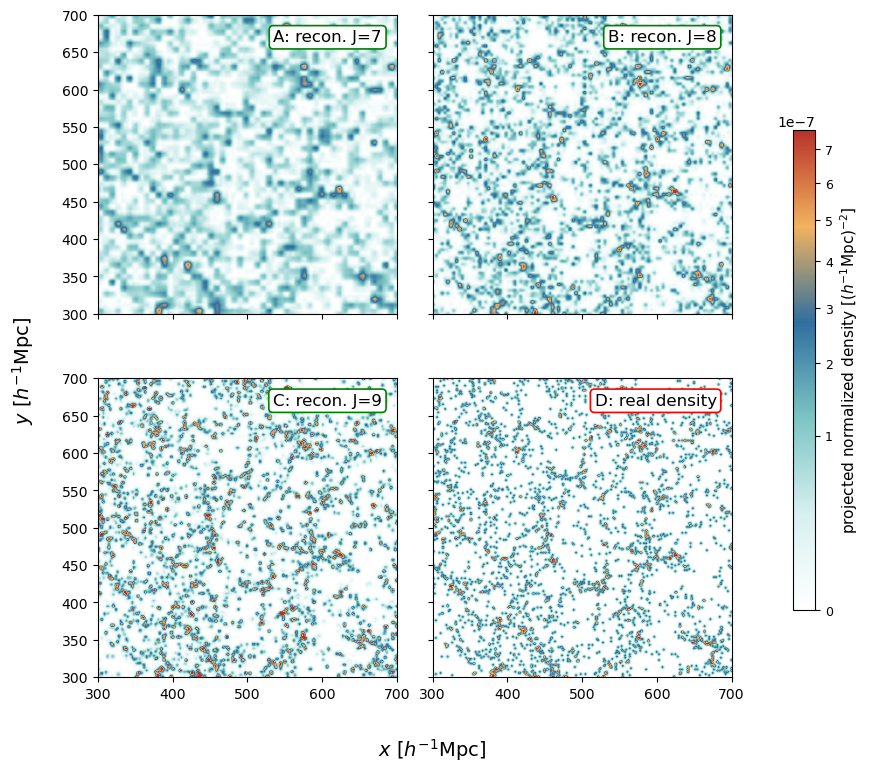

In [20]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize, PowerNorm
from scipy.ndimage import gaussian_filter

def reconstructed_projected_density(field, nx=192, nz=12, chunk_size=262_144):
    x = np.linspace(x_range[0], x_range[1], nx)
    y = np.linspace(y_range[0], y_range[1], nx)
    z = (slice_z + np.linspace(-0.5 * slice_thickness, 0.5 * slice_thickness, nz, endpoint=False)
         + 0.5 * slice_thickness / nz) % box_size
    xx, yy = np.meshgrid(x, y, indexing='ij')
    xy = np.column_stack([xx.ravel(), yy.ravel()])
    projected = np.zeros(xx.size, dtype=np.float64)
    dz = slice_thickness / nz

    for zk in z:
        pos = np.empty((xy.shape[0], 3), dtype=np.float64)
        pos[:, :2] = xy
        pos[:, 2] = zk
        rho = np.empty(pos.shape[0], dtype=np.float64)
        for start in range(0, pos.shape[0], chunk_size):
            stop = min(start + chunk_size, pos.shape[0])
            rho[start:stop] = field.field_density_at_pos(pos[start:stop], value_unit='physical')
        projected += rho * dz

    return projected.reshape(nx, nx)


def halo_projected_density_reference(halo_cut, particle_count, nx=192):
    pixel_area = ((x_range[1] - x_range[0]) / nx) * ((y_range[1] - y_range[0]) / nx)
    weights = np.full(halo_cut.shape[0], 1.0 / particle_count)
    hist, _, _ = np.histogram2d(
        halo_cut[:, 0],
        halo_cut[:, 1],
        bins=nx,
        range=[x_range, y_range],
        weights=weights,
    )
    return hist / pixel_area


def smooth_for_display(image, nx, smooth_mpc):
    if smooth_mpc <= 0.0:
        return image
    sigma_pix = smooth_mpc * nx / (x_range[1] - x_range[0])
    return gaussian_filter(image, sigma=sigma_pix, mode='nearest')

reconstruct_nx = 256
reconstruct_nz = 16
display_smooth_mpc = 1  # Set to 0.0 to show the reconstructed map without display-only smoothing.
use_power_norm = True    # Set True to brighten low-density filaments.
gamma = 0.5              # PowerNorm gamma value for low-density brightening.

recon_maps = [
    reconstructed_projected_density(D7, nx=reconstruct_nx, nz=reconstruct_nz),
    reconstructed_projected_density(D8, nx=reconstruct_nx, nz=reconstruct_nz),
    reconstructed_projected_density(D9, nx=reconstruct_nx, nz=reconstruct_nz),
]
halo_recon_ref = halo_projected_density_reference(halo_cut, D8.particle_count, nx=reconstruct_nx)
display_maps = [smooth_for_display(np.clip(image, 0.0, None), reconstruct_nx, display_smooth_mpc)
                for image in [*recon_maps, halo_recon_ref]]
positive_values = np.concatenate([image[image > 0] for image in display_maps])
vmax = np.percentile(positive_values, 99.7)
if use_power_norm:
    density_norm = PowerNorm(gamma=gamma, vmin=0.0, vmax=vmax)
else:
    density_norm = Normalize(vmin=0.0, vmax=vmax)

density_cmap = LinearSegmentedColormap.from_list(
    'reconstructed_density',
    ['#ffffff', '#d7f0f0', '#7cc4c4', '#2f6f9f', '#f2b35e', '#b8322a'],
)

fig, axes = plt.subplots(2, 2, figsize=(8.8, 8), sharex=True, sharey=True)
extent = (*x_range, *y_range)
panels = [
    (axes[0, 0], display_maps[0], 'A: recon. J=7', 'green'),
    (axes[0, 1], display_maps[1], 'B: recon. J=8', 'green'),
    (axes[1, 0], display_maps[2], 'C: recon. J=9', 'green'),
    (axes[1, 1], display_maps[3], 'D: real density', 'red'),
]

for ax, image, label, edgecolor in panels:
    ax.imshow(
        image.T,
        origin='lower',
        extent=extent,
        cmap=density_cmap,
        norm=density_norm,
        interpolation='bilinear',
    )
    ax.text(0.95, 0.95, label, transform=ax.transAxes, ha='right', va='top', fontsize=12,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor=edgecolor, linewidth=1.2))

for ax in axes.ravel():
    ax.set_xlim(*x_range)
    ax.set_ylim(*y_range)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=10)
    ax.label_outer()

fig.supxlabel(r'$x\ [h^{-1}\mathrm{Mpc}]$', fontsize=14)
fig.supylabel(r'$y\ [h^{-1}\mathrm{Mpc}]$', fontsize=14)
fig.subplots_adjust(left=0.12, right=0.84, bottom=0.10, top=0.96, wspace=0.12, hspace=0.12)

mappable = ScalarMappable(norm=density_norm, cmap=density_cmap)
mappable.set_array([])
cbar_ax = fig.add_axes([0.91, 0.20, 0.025, 0.60])
cbar = fig.colorbar(mappable, cax=cbar_ax)
cbar.set_label(r'projected normalized density [$(h^{-1}\mathrm{Mpc})^{-2}$]', fontsize=11)
cbar.ax.tick_params(labelsize=9)

figs_dir = Path('figs')
figs_dir.mkdir(exist_ok=True)
fig.savefig(figs_dir / 'sfc_field_reconstructed_density_j7_j8_j9_halo_binned.png', dpi=200, bbox_inches='tight')

plt.show()
